# Synergy prediction using bulk RNA-seq data

## Data loading

In [19]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import functools
from functools import reduce

Load the time-matched log2foldchange data and the CFU data.

In [20]:
from src.dge_data import get_l2fc_and_cfu_data

# Local data directories
cfu_dir = "C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/all_cfus"
l2fc_dir = "C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/dge_timezero"

# Data pipeline
data_df = get_l2fc_and_cfu_data(l2fc_dir, cfu_dir, time_matched = True)

Attach all relevant metadata.

In [21]:
from src.metadata import attach_metadata

data_df = attach_metadata(data_df)

ImportError: cannot import name 'attach_metadata' from 'src.metadata' (c:\Users\eddyk\cloned_repos\rnaseq_cfu_regressor\notebooks\..\src\metadata.py)

In [13]:
data_df.columns

Index(['F01-SP0085-SP0086', 'F02-SP0103-SP0104', 'F03-SP0115-SP0116',
       'F04-SP0116-SP0117', 'F05-SP0117-SP0118', 'F06-SP0129-SP0130',
       'F07-SP0239-SP0240', 'F08-SP0256-SP0257', 'F09-SP0257-SP0258',
       'F10-SP0311-SP0312',
       ...
       'SP_2231', 'SP_2233', 'SP_2234', 'SP_2235', 'SP_2236', 'SP_2237',
       'SP_2238', 'SP_2239', 'SP_2240', 'CFU'],
      dtype='str', length=2192)

Construct a dataframe for synergy prediction that contains transcriptional interaction for each gene (computed from l2fc of monotherapies and combination), as well as synergy score as the prediction target.

In [9]:
from src.dge_data import simple_interaction_score, eob_score, hsa_score

def construct_synergy_df(df, interaction_score_method, synergy_score_method):
    """
    Function to construct a dataframe for synergy prediction. Each condition corresponds to a drug combination,
    and each feature will be a transcriptional interaction score calculated according to specified function.
    There will be one column of synergy score as the prediction target.

    Args:
        combo_df                 : Dataframe containing all log2foldchange data and metadata
        interaction_score_method : Function for calculating transcriptional interaction
        synergy_score_method     : Function for calculating synergy using survival fraction

    Returns:
        synergy_df : Dataframe with transcriptaional interaction score as features and EOB score as prediction target
    """
    # Check that the only unique num_drugs are 1 and 2
    unique_num_drugs = df["num_drugs"].unique()

    if set(unique_num_drugs) != [1, 2]:
        return KeyError("num_drugs column contains values other than 1, 2")
    
    # Separate data df into single and combination data
    single_df = df.iloc[(df["num_drugs"] == 1).to_numpy()]
    combo_df = df.iloc[(df["num_drugs"] == 2).to_numpy()]
    
    # Store data size
    num_single = single_df.shape[0]
    num_combos = combo_df.shape[0]

    # Identify gene / transcript columns
    gene_cols = combo_df.columns[combo_df.columns.str.contains("SP", na = False)]
    
    rows = []

    for i in range(num_combos):

        # Store current combo data and specify drug 1, drug 2, doses, and timepoint
        combo_data = combo_df.iloc[i]
        combo_id = combo_df.index[i]
        drug1 = combo_data["drug1"]
        drug2 = combo_data["drug2"]
        drug1_dose = combo_data["drug1_dose"]
        drug2_dose = combo_data["drug2_dose"]
        timepoint = combo_data["timepoint"]

        # Select the two corresponding single drug datapoints from the single drug dataframe
        single_data1_bool = [
            i for i in range(num_single) if 
            single_df.iloc[i]["drug1"] == drug1
            and pd.isna(single_df.iloc[i]["drug2"])
            and single_df.iloc[i]["drug1_dose"] == drug1_dose
            and single_df.iloc[i]["timepoint"] == timepoint
        ]
        single_data2_bool = [
            i for i in range(num_single) if 
            single_df.iloc[i]["drug1"] == drug2
            and pd.isna(single_df.iloc[i]["drug2"])
            and single_df.iloc[i]["drug1_dose"] == drug2_dose 
            and single_df.iloc[i]["timepoint"] == timepoint
        ]
        single_data1 = single_df.iloc[single_data1_bool].iloc[0]
        single_data2 = single_df.iloc[single_data2_bool].iloc[0]
        
        # Extract the survival fractions and compute synergy score
        surv_frac_combo = combo_data["survival_fraction"]
        surv_frac1 = single_data1["survival_fraction"]
        surv_frac2 = single_data2["survival_fraction"]

        synergy_score = synergy_score_method(surv_frac1, surv_frac2, surv_frac_combo)

        # Extract gene expression values
        l2fc_1 = single_data1[gene_cols]
        l2fc_2 = single_data2[gene_cols]
        l2fc_combo = combo_data[gene_cols]
        
        # Compute transcriptional interaction score for each gene
        interaction_scores = {
            gene: interaction_score_method(v_a, v_b, v_ab)
            for gene, v_a, v_b, v_ab in zip(
                gene_cols,
                l2fc_1,
                l2fc_2,
                l2fc_combo
            )
        }

        # Build row
        row = {
            "ID": combo_id,
            "drug1": drug1,
            "drug2": drug2,
            "drug1_dose": drug1_dose,
            "drug2_dose": drug2_dose,
            "timepoint": timepoint,
            **interaction_scores,
            "synergy_score": synergy_score
        }
        rows.append(row)
    
    # Construct dataframe and move condition label to index
    synergy_df = pd.DataFrame(rows)
    synergy_df = synergy_df.set_index("ID")

    return synergy_df

Run on our data.

In [12]:
# Bliss synergy df
bliss_df = construct_synergy_df(
    df = data_df,
    interaction_score_method = simple_interaction_score,
    synergy_score_method = eob_score
)

# HSA synergy df
hsa_df = construct_synergy_df(
    df = data_df,
    interaction_score_method = simple_interaction_score,
    synergy_score_method = hsa_score
)

KeyError: 'num_drugs'

## Training model

Simple train test split to start.

0.49328622983598025


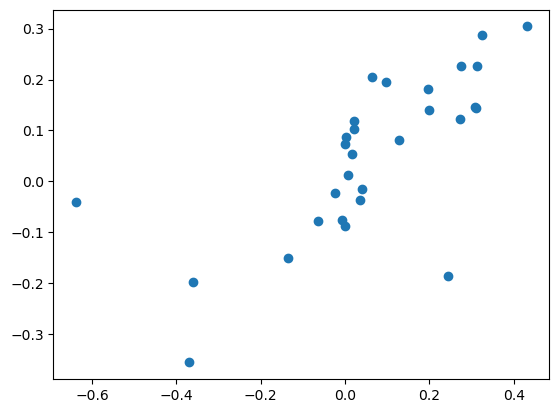

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
%matplotlib inline

X = hsa_df.iloc[:, bliss_df.columns.str.contains("SP")].dropna(axis = 1) # remove NA features
y = hsa_df["synergy_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 120)

model = ElasticNetCV()

model.fit(X_train, y_train)

preds = model.predict(X_test)

score = r2_score(y_test, preds)
print(score)

plt.scatter(y_test, preds)